# Visión por computadora I
## Trabajo práctico 3

**Integrantes:**
* Diego Vazquez
* Hernando Scheidl
* Martín Lacheski
* Nicolás Lastra

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template`. Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección.

### Preparación

Cargamos las imágenes y el template, y definimos las funciones para visualizar los resultados.

In [1]:
import glob
import os

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

RAIZ = '../../Material_TPs/TP3/'


def cargar(path, grises=False):
    """Lee la imagen aplanando el canal alfa sobre fondo blanco."""
    im = cv.imread(path, cv.IMREAD_UNCHANGED)
    if im.shape[2] == 4:
        a = im[:, :, 3:4] / 255.0
        im = (im[:, :, :3] * a + 255 * (1 - a)).astype(np.uint8)
    return cv.cvtColor(im, cv.COLOR_BGR2GRAY) if grises else im


# Template recortado al logo (sin margen blanco)
template = cargar(RAIZ + 'template/pattern.png', grises=True)
ys, xs = np.where(template < 200)
template = template[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
w, h = template.shape[::-1]
paths = sorted(glob.glob(RAIZ + 'images/*'))


def dibujar(img, dets):
    """Dibuja las bounding boxes (x0, y0, x1, y1, confianza, ...) con su confianza."""
    out = img.copy()
    for x0, y0, x1, y1, conf, *_ in dets:
        cv.rectangle(out, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 2)
        cv.putText(out, f'{conf:.2f}', (int(x0), max(12, int(y0) - 4)), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return out


def mostrar(paths, detector, cols=3):
    filas = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=(6 * cols, 5 * filas))
    for i, p in enumerate(paths):
        img = cargar(p)
        dets = detector(img)
        plt.subplot(filas, cols, i + 1)
        plt.imshow(cv.cvtColor(dibujar(img, dets), cv.COLOR_BGR2RGB))
        plt.title(f'{os.path.basename(p)}: {len(dets)} detección(es)')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### 1. Obtener una detección del logo en cada imagen sin falsos positivos

Usamos SIFT + matching + homografía:
- Usamos el template y su negativo, porque el logo aparece rojo sobre blanco y también blanco sobre rojo.
- Hacemos el matching con FLANN y nos quedamos con los matches que pasan el test de Lowe.
- Con esos matches calculamos la homografía con RANSAC, que lleva las esquinas del template a la imagen.
- Dibujamos la bounding box que envuelve al polígono. La confianza es la fracción de matches que RANSAC valida como inliers.
- Nos quedamos con la detección con más inliers entre el template y su negativo.

In [2]:
sift = cv.SIFT_create()
flann = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
pts = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
plantillas = [sift.detectAndCompute(t, None) for t in (template, 255 - template)]

RATIO = 0.7           # test de Lowe
UMBRAL_RANSAC = 3.0   # px
MIN_INLIERS = 8


def detectar_uno(img):
    """Devuelve [(x0, y0, x1, y1, confianza, inliers)] con la mejor detección, o []."""
    cv.setRNGSeed(0)
    kp2, des2 = sift.detectAndCompute(cv.cvtColor(img, cv.COLOR_BGR2GRAY), None)
    mejor = []
    for kp1, des1 in plantillas:
        matches = [m for m in flann.knnMatch(des1, des2, k=2) if len(m) == 2]
        good = [a for a, b in matches if a.distance < RATIO * b.distance]
        if len(good) < MIN_INLIERS:
            continue
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, UMBRAL_RANSAC)
        if M is not None and mask.sum() >= MIN_INLIERS and (not mejor or mask.sum() > mejor[0][5]):
            q = cv.perspectiveTransform(pts, M).reshape(-1, 2)
            mejor = [(*q.min(axis=0), *q.max(axis=0), float(mask.mean()), int(mask.sum()))]
    return mejor

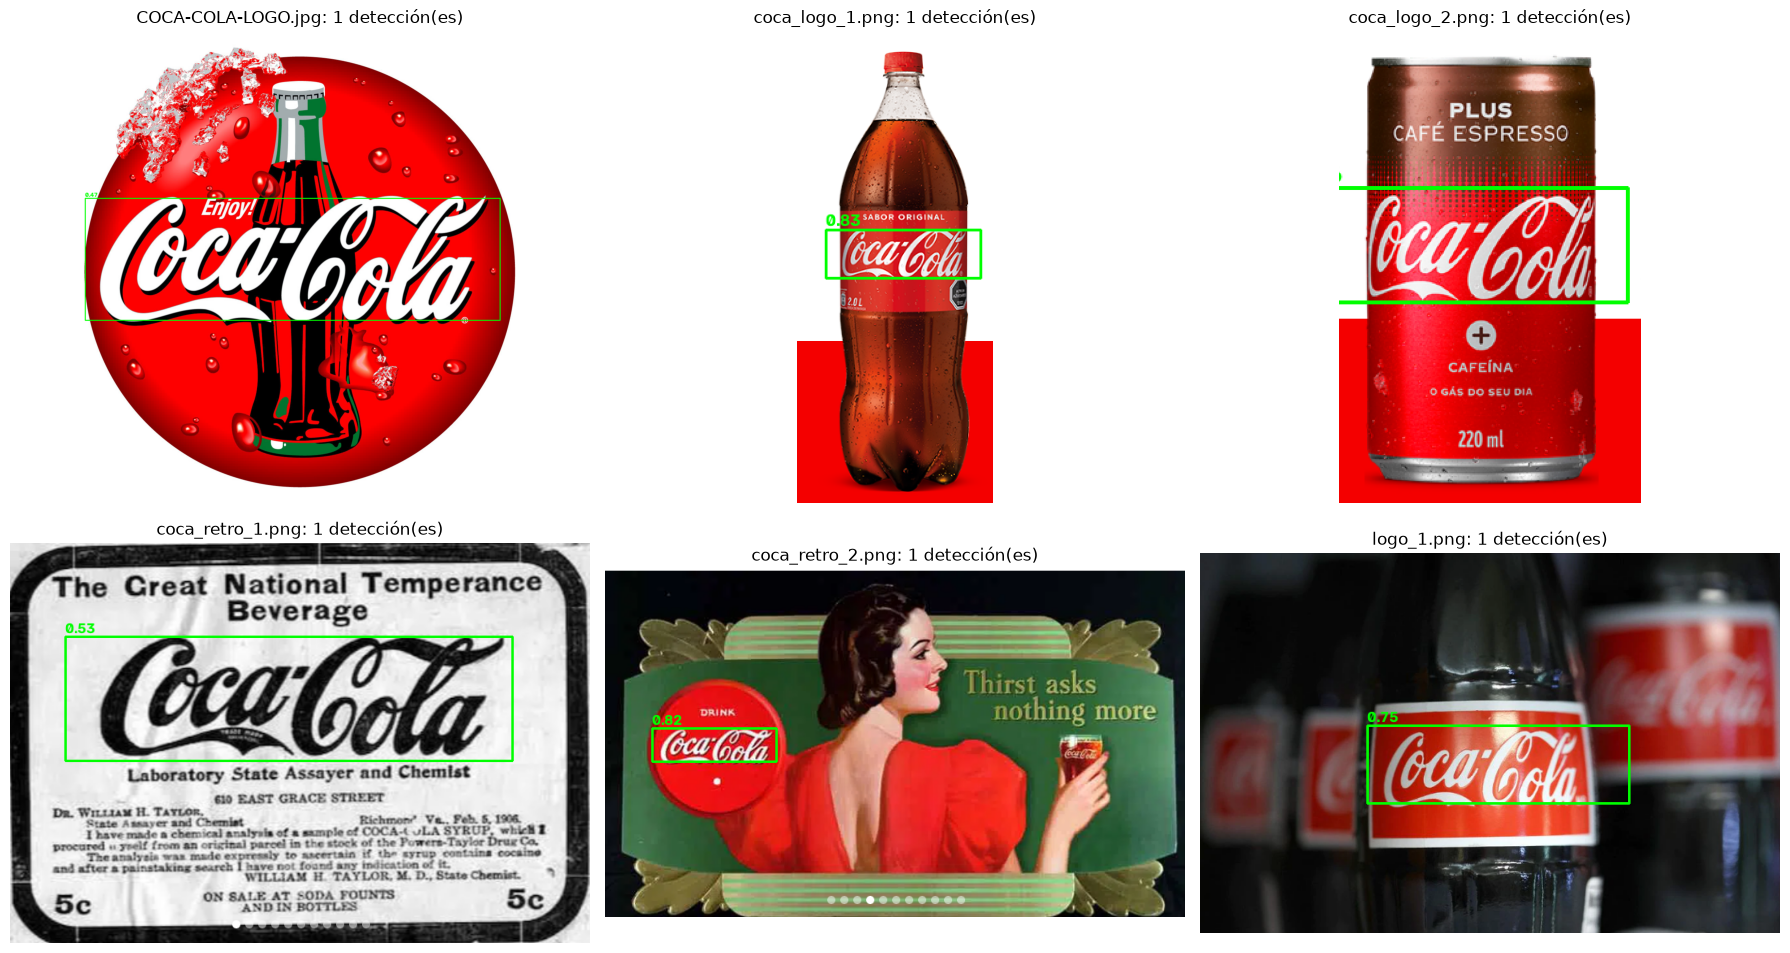

In [3]:
mostrar([p for p in paths if 'multi' not in p], detectar_uno)

### 2. Plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo template del ítem 1

Hacemos template matching (`TM_CCOEFF_NORMED`) sobre mapas de bordes de Canny, con el umbral de Canny tomado de Otsu. Probamos varias escalas del logo (entre el 6% del ancho de la imagen y el máximo que entra), aceptamos los puntos con score >= 70% del máximo y suprimimos los no-máximos con IoU.

16 logos detectados


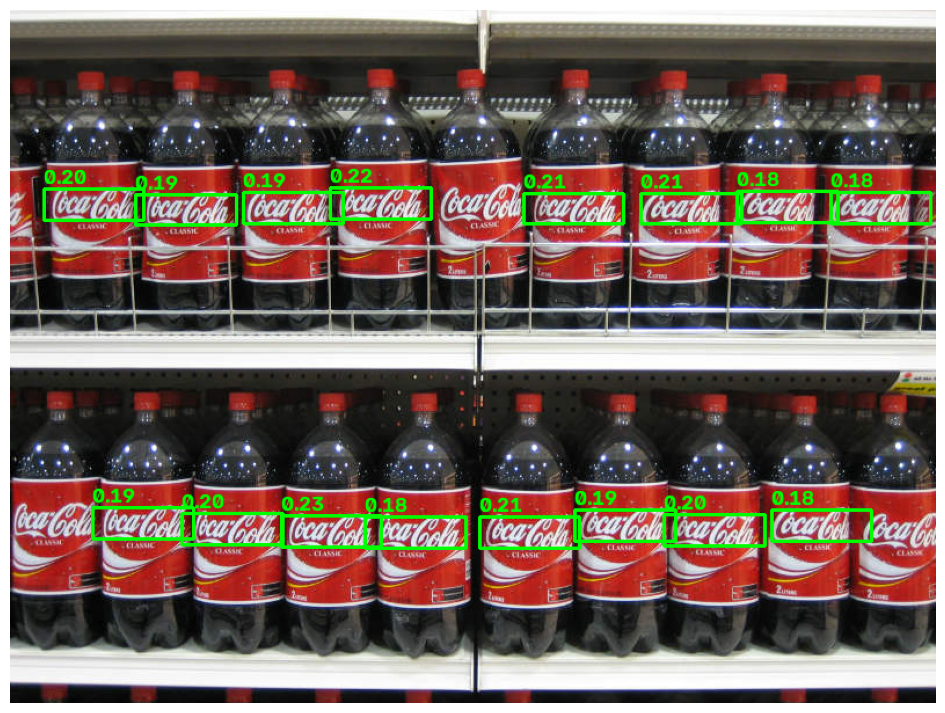

In [4]:
REL = 0.7         # score mínimo, relativo al máximo
ANCHO_REF = 100   # ancho (px) al que llevamos el logo en cada escala


def bordes(gray):
    blur = cv.GaussianBlur(gray, (5, 5), 0)
    t, _ = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    edges = cv.Canny(blur, 0.5 * t, t)
    return edges.astype(np.float32)


def iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    return inter / ((a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter)


def detectar_tm(img):
    """Devuelve una lista de (x0, y0, x1, y1, score)."""
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    H, W = gray.shape
    # el logo de referencia mide ANCHO_REF px; se reescala la imagen
    alto_ref = round(ANCHO_REF * h / w)
    t_bordes = bordes(cv.resize(template, (ANCHO_REF, alto_ref)))
    mapas = []
    for ancho in np.linspace(max(40, 0.06 * W), min(W, H * w / h), 40):
        f = ANCHO_REF / ancho
        g = cv.resize(gray, None, fx=f, fy=f)
        if g.shape[0] > alto_ref and g.shape[1] > ANCHO_REF:
            mapas.append((ancho, f, cv.matchTemplate(bordes(g), t_bordes, cv.TM_CCOEFF_NORMED)))

    threshold = REL * max(res.max() for _, _, res in mapas)
    dets = []
    for ancho, f, res in mapas:
        ys, xs = np.where(res >= threshold)
        dets += [(x / f, y / f, x / f + ancho, y / f + ancho * h / w, float(res[y, x])) for x, y in zip(xs, ys)]

    # supresión de no-máximos: el de mayor score gana
    final = []
    for d in sorted(dets, key=lambda d: -d[4]):
        if all(iou(d, k) < 0.3 for k in final):
            final.append(d)
    return final


multi = cargar(RAIZ + 'images/coca_multi.png')
dets = detectar_tm(multi)
print(f'{len(dets)} logos detectados')

plt.figure(figsize=(12, 9))
plt.imshow(cv.cvtColor(dibujar(multi, dets), cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### 3. Generalizar el algoritmo del ítem 2 para todas las imágenes

Generalizamos la detección múltiple del ítem 2 para que funcione en todas las imágenes, tengan 1 logo o muchos. Para eso usamos SIFT + matching + homografía, extendido para detectar tantos logos como haya:
- El matching va de la imagen al template: así el test de Lowe no falla cuando el logo está repetido en la imagen.
- Cada match vota por el centro y la escala del logo. Tomamos el grupo más votado, calculamos la homografía con RANSAC sólo con esos matches, los descartamos y repetimos hasta que no queden grupos con suficientes matches.

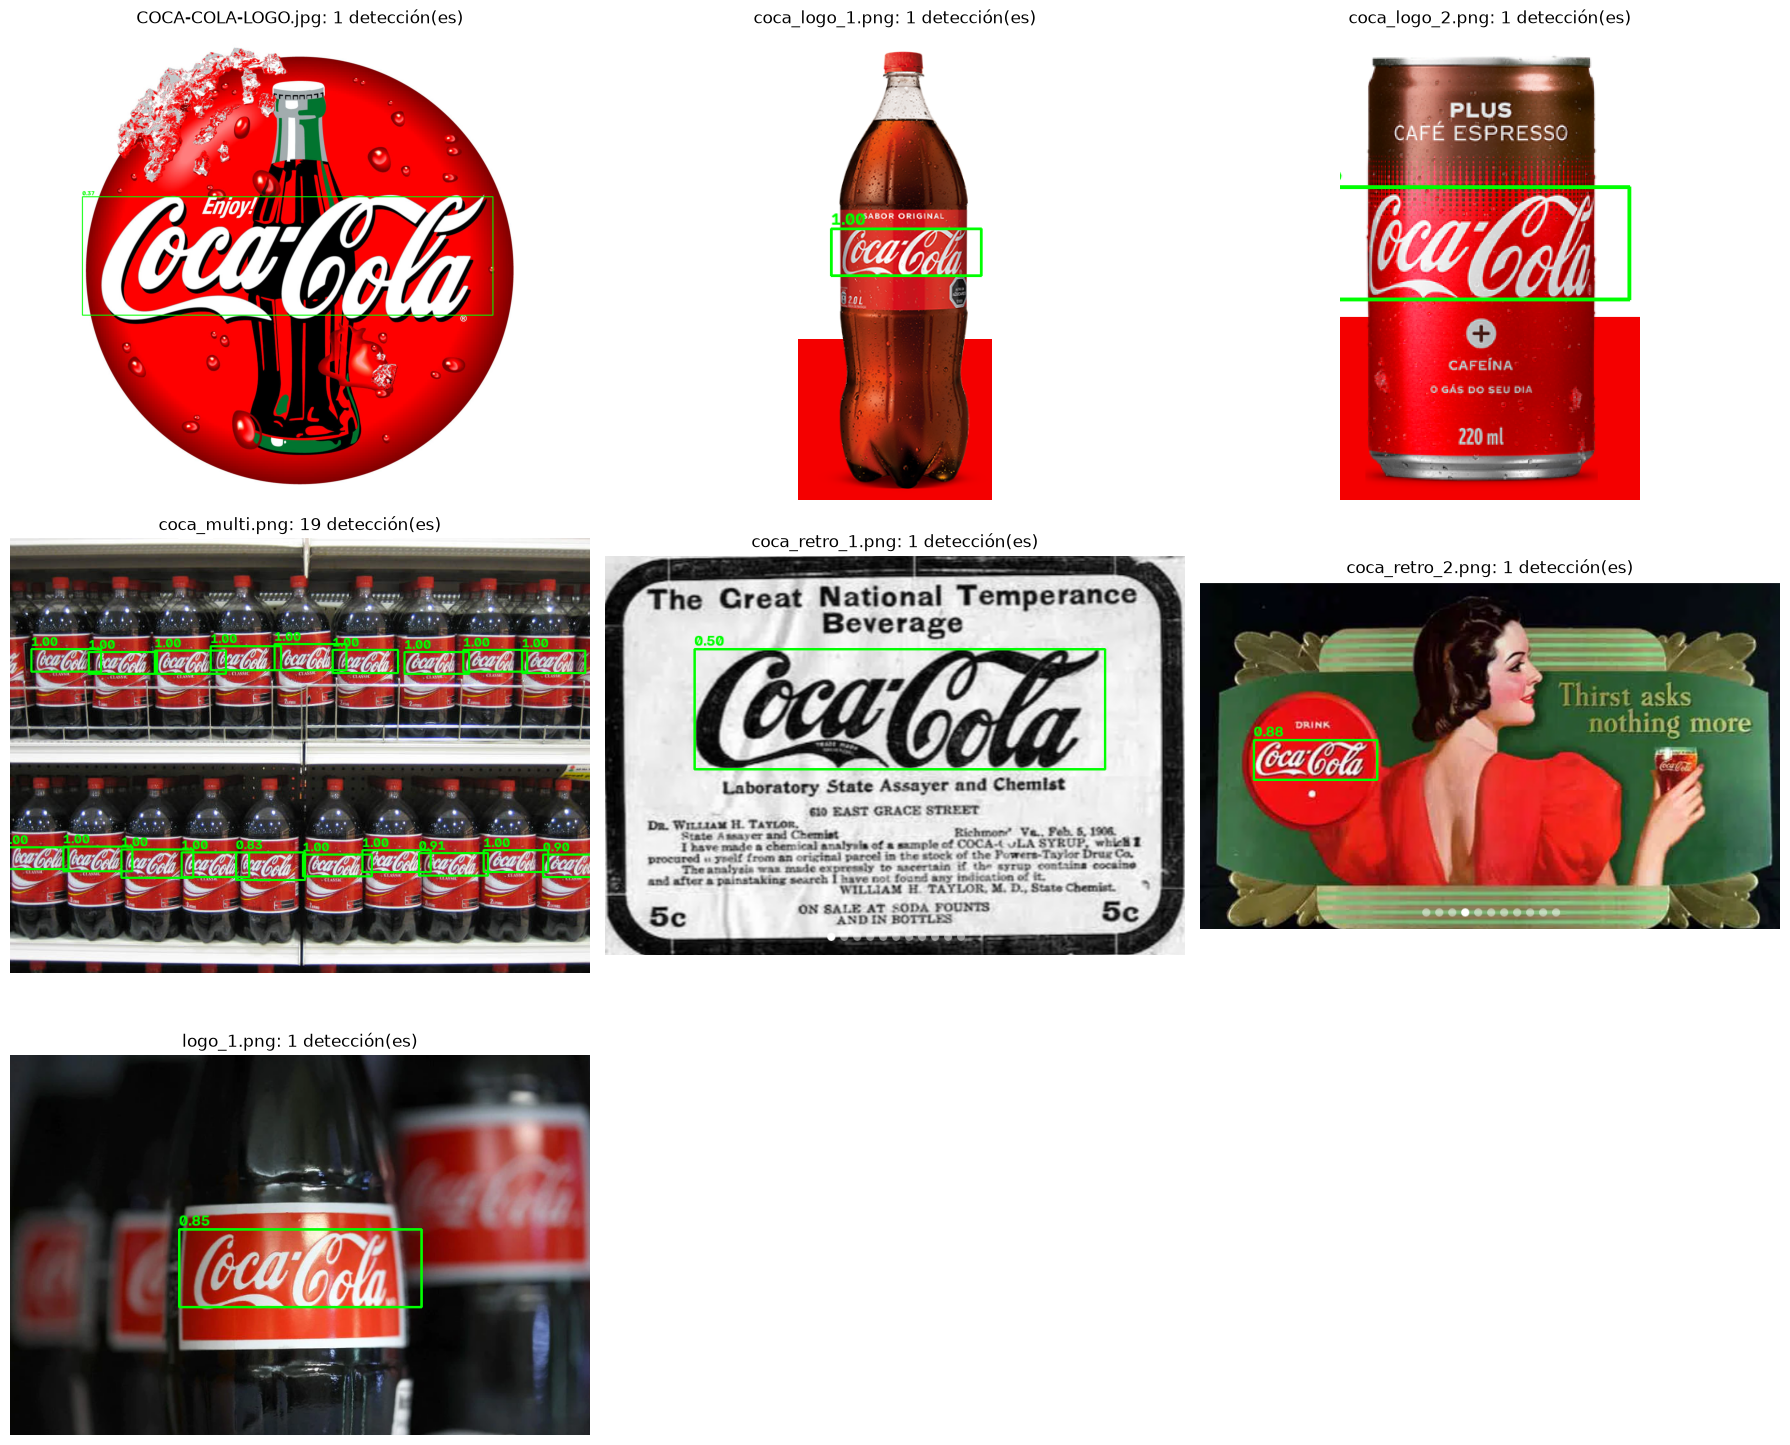

In [5]:
def detectar_sift(img):
    """Devuelve una lista de (x0, y0, x1, y1, confianza, inliers), una por logo."""
    cv.setRNGSeed(0)
    kp2, des2 = sift.detectAndCompute(cv.cvtColor(img, cv.COLOR_BGR2GRAY), None)
    dets = []
    for kp1, des1 in plantillas:
        # matching imagen -> template con test de Lowe
        matches = [m for m in flann.knnMatch(des2, des1, k=2) if len(m) == 2]
        good = [a for a, b in matches if a.distance < RATIO * b.distance]

        # cada match vota por el centro y la escala del logo
        escalas = np.array([kp2[m.queryIdx].size / kp1[m.trainIdx].size for m in good])
        votos = np.array([kp2[m.queryIdx].pt - s * (np.array(kp1[m.trainIdx].pt) - [w / 2, h / 2])
                          for m, s in zip(good, escalas)])

        vivo = np.ones(len(good), bool)
        while vivo.sum() >= MIN_INLIERS:
            idx = np.where(vivo)[0]
            dist = np.linalg.norm(votos[idx][:, None] - votos[idx][None], axis=2)
            dif_escala = np.abs(np.log(escalas[idx][:, None] / escalas[idx][None]))
            cerca = (dist < 0.35 * w * escalas[idx][:, None]) & (dif_escala < 0.5)
            j = cerca.sum(axis=1).argmax()
            if cerca[j].sum() < MIN_INLIERS:
                break
            grupo = idx[cerca[j]]
            vivo[grupo] = False
            src_pts = np.float32([kp1[good[i].trainIdx].pt for i in grupo]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[good[i].queryIdx].pt for i in grupo]).reshape(-1, 1, 2)
            M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, UMBRAL_RANSAC)
            if M is not None and mask.sum() >= MIN_INLIERS:
                q = cv.perspectiveTransform(pts, M).reshape(-1, 2)
                dets.append((*q.min(axis=0), *q.max(axis=0), float(mask.mean()), int(mask.sum())))
    return dets


mostrar(paths, detectar_sift)